# Model Training and Evaluation Pipeline: Geo-conditioned U-Net Mixture-of-Experts(GUM)

## Overview
This document details the training and evaluation workflow for the GUM. The pipeline covers feature assembly, stratified data splitting, normalization, model training, and comprehensive performance evaluation across different sky conditions and times of day.

---

## 1. Data Assembly and Feature Engineering
The initial phase combines satellite band data with geographic elevation features to create the final input tensors for the model. 

* **Input Sources:** * Satellite Bands: `bands_day_paired_no_twillight.npz` (10 selected channels)
  * Elevation Data: `hk_geom_50x50.npz`
* **Output Tensor Configuration:**
  * **X (Features):** Shape `(67638, 12, 50, 50)`
  * **y (Target CSI):** Shape `(67638, 1, 50, 50)`

## 2. Stratified Data Splitting
To ensure robust model evaluation, the dataset is split chronologically while stratifying across clear and cloudy sky conditions (using thresholds: `clear_thr=0.8`, `cloudy_thr=0.35`).

* **Training Set:** 80% (54,101 samples) | Mean Target: 0.6992
* **Validation Set:** 10% (6,783 samples) | Mean Target: 0.6975
* **Test Set:** 10% (6,754 samples) | Mean Target: 0.6985

> **Note:** Channel minimum and maximum values for normalization (`channel_min`, `channel_max`) are calculated **strictly on the Training Set** to prevent data leakage, then applied across all datasets via the `BandsCamsDataset` class using a batch size of 64.

---

## 3. Model Architecture and Training
The model utilizes a spatial gating mechanism to blend predictions from multiple experts.

* **Model Architecture:** `GUM` (Gated Unified Model)
  * **Feature Size:** 64
  * **Experts (K):** 2
  * **Gate Temperature:** 0.5
* **Training Hyperparameters:**
  * **Epochs:** 50
  * **Learning Rate:** `1e-4` (Max `3e-4`)
  * **Weight Decay:** `1e-3`
  * **Checkpoint:** `best_gum.pt`

---

## 4. Evaluation and Performance Metrics
The best model checkpoint is evaluated on the Test Set. Performance is measured using Clear Sky Index (CSI) and Global Horizontal Irradiance (GHI) across varying temporal and meteorological categories.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from torch.utils.data import DataLoader
import torch 
from src.utils import (
    stratified_split_grouped_by_time,
    make_labels,
    summarize_split_csi_mean
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train import(
    train_gum,gate_stats,)

from src.evaluate import(
    evaluate_table_metrics
)
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.plot import(
    plot_full_images_from_loader,
)
from src.model import GUM

## 1. Data Assembly and Feature Engineering

In [ ]:
bands_npz_name = "../Data/bands/modeldata/bands_day_paired_no_twillight.npz"
elevation_npz_name = "../Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [ ]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="../Data/output/bands_day_pairs_with_elevation.npz",
)
print("Saved:", out)
print("Final shape:", shape)

Saved: Data/output/day_pairs_with_elevation.npz
Final shape: (67638, 12, 50, 50)


In [ ]:
X, y = load_bands_and_cams(
    bands_npz_path="../Data/output/bands_day_pairs_with_elevation.npz",
    cams_npz_path="../Data/CAMS/modeldata/cams_day_paired_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (67638, 12, 50, 50)
y shape: (67638, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.048625361174345016 max 1.0


## 2. Stratified Data Splitting

In [ ]:
cams = np.load("../Data/CAMS/modeldata/cams_day_paired_no_twillight.npz")
t = cams["time_min"]
cams_data = cams["data"]

c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_split_grouped_by_time(labels, t, 0.8, 0.1, 0.1, seed=42)
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

train | N= 54101 | mean=0.6992 std=0.2686 | p05=0.1851 p50=0.7892 p95=0.9917 | min=0.0577 max=0.9997
  val | N=  6783 | mean=0.6975 std=0.2671 | p05=0.1872 p50=0.7808 p95=0.9916 | min=0.0588 max=0.9992
 test | N=  6754 | mean=0.6985 std=0.2688 | p05=0.1829 p50=0.7875 p95=0.9916 | min=0.0592 max=0.9977


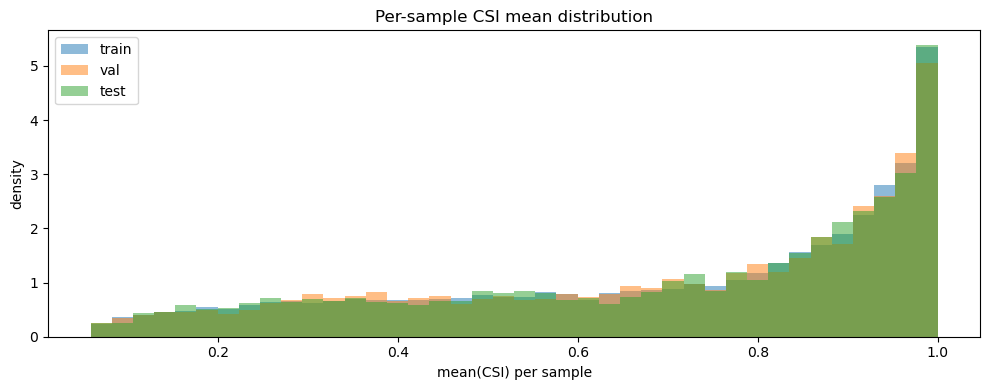

In [4]:
report = summarize_split_csi_mean(
    y,
    idx_train=idx_train,
    idx_val=idx_val,
    idx_test=idx_test,
    bins=40,
    plot=True
)

In [5]:
channel_min = np.nanmin(X_train, axis=(0, 2, 3))  
channel_max = np.nanmax(X_train, axis=(0, 2, 3))

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

np.savez(
    "Data/static/minmax_strat.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)

In [ ]:
train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=8, pin_memory=True,
    persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


## 3. Model Architecture and Training

In [16]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)
model = GUM(feature_size=64, K=2, gate_temp=0.5).to(device)
print(gate_stats(model, val_loader, device, K=2))

{'hard_usage': array([0.85854036, 0.14145966], dtype=float32), 'mean_max_weight': 0.660917192697525, 'mean_entropy': 0.5968061089515686}


In [ ]:
best_ckpt = train_gum(
    model, train_loader, val_loader, device,
    total_epochs=50,
    lr=1e-4, max_lr=3e-4,
    weight_decay=1e-3,
    lam_bal=0.001,
    full_val_every=5,
    val_batches_quick=30,
    ckpt_name="best_gum.pt"
)

## 4. Evaluation and Performance Metrics

In [ ]:
# --- load best model for evaluation ---
PATH = "../Model_checkpoint/best_gum.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sd = torch.load(PATH, map_location=device)["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd)

<All keys matched successfully>

In [ ]:
df_results = evaluate_table_metrics(
    model, 
    test_loader, 
    device, 
    cs_ghi_full=c1, 
    time_mins_full=t, 
    idx_eval=idx_test
)
display(df_results)

RMSE  rRMSE (%)        MAE       MBE        R2
Target Category / Period                                                     
CSI    Clear sky           0.058814   6.361044   0.029333  0.002754  0.801713
       Cloudy sky          0.101286  44.685726   0.071073  0.010675  0.584396
       Morning (5-8)       0.124283  17.416612   0.075138 -0.005657  0.833386
       Day (8-16)          0.081306  11.662442   0.049409  0.003139  0.933432
       Evening (16-19)     0.100509  14.415968   0.062275  0.002110  0.895370
       Overall (All sky)   0.088889  12.725156   0.053598  0.002244  0.919653
GHI    Clear sky          36.465481   6.607553  16.845308  1.800518  0.978962
       Cloudy sky         57.569679  45.063473  38.240127  8.038481  0.724787
       Morning (5-8)      28.885492  17.526460  16.823689  0.093185  0.904229
       Day (8-16)         57.375638  11.859860  33.636900  2.771510  0.953707
       Evening (16-19)    25.370011  13.225471  15.503158  1.773815  0.963169
       Overall (All sky)  51.628739  12.569973  29.348737  2.389950  0.964019

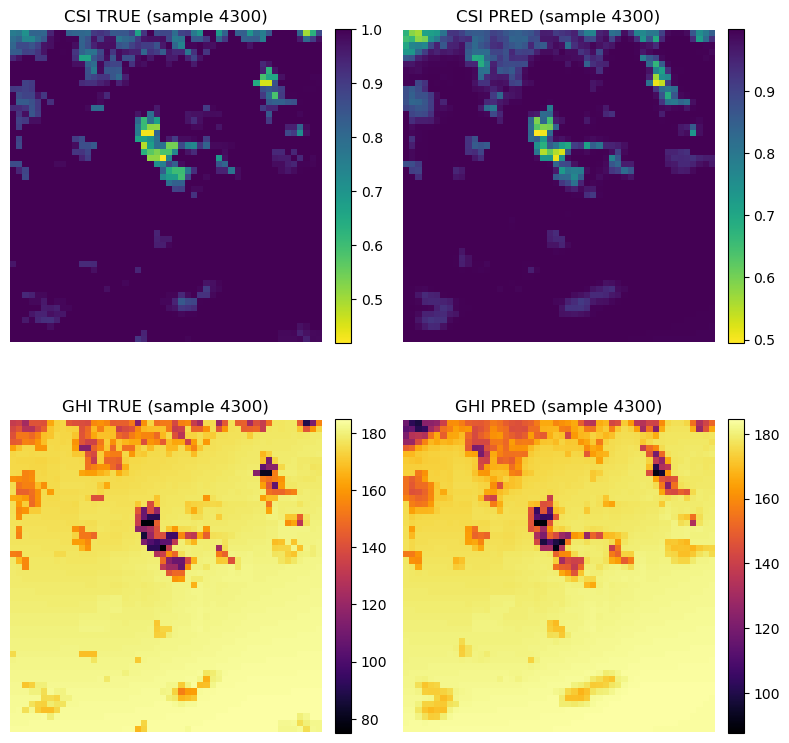

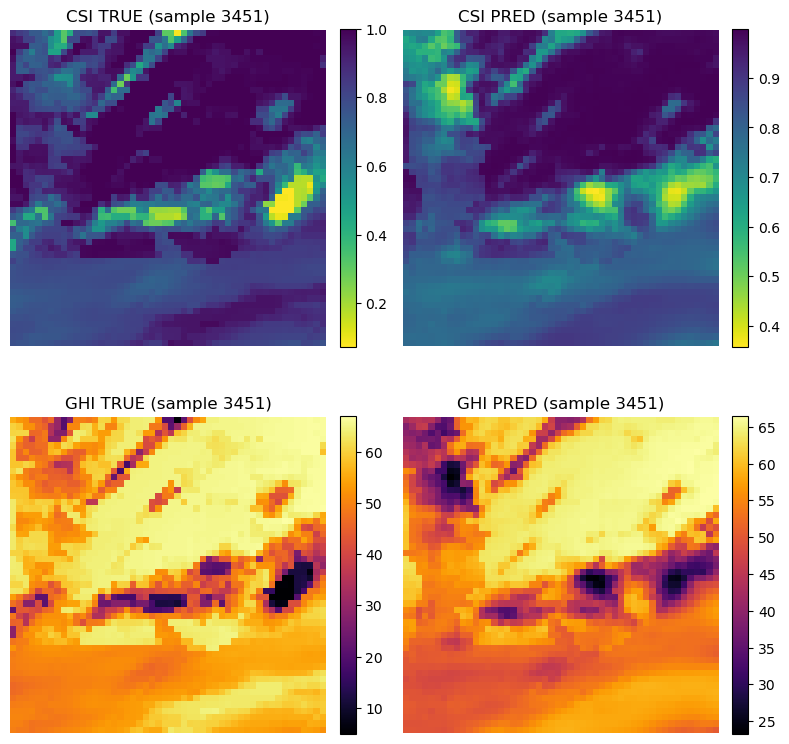

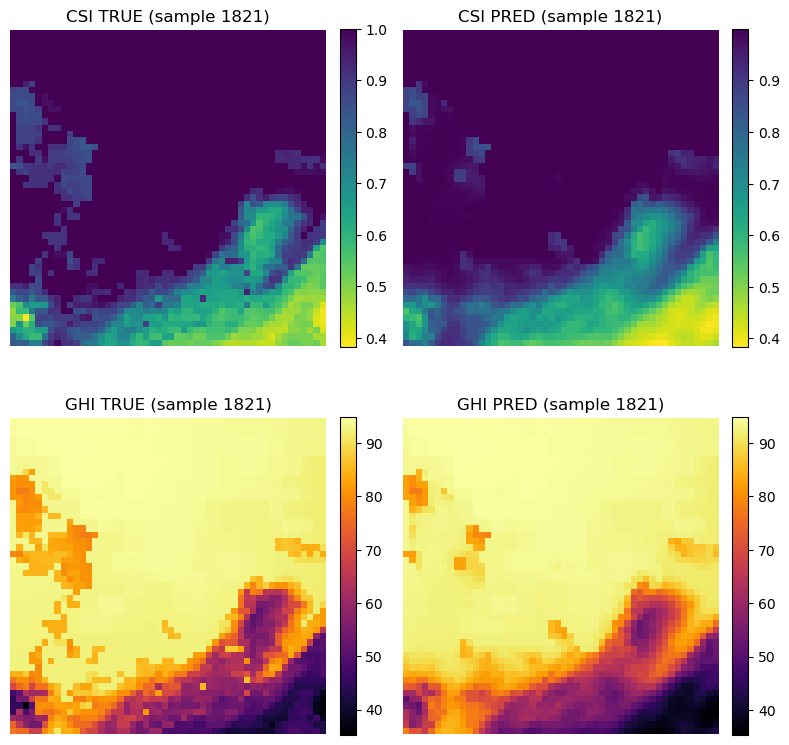

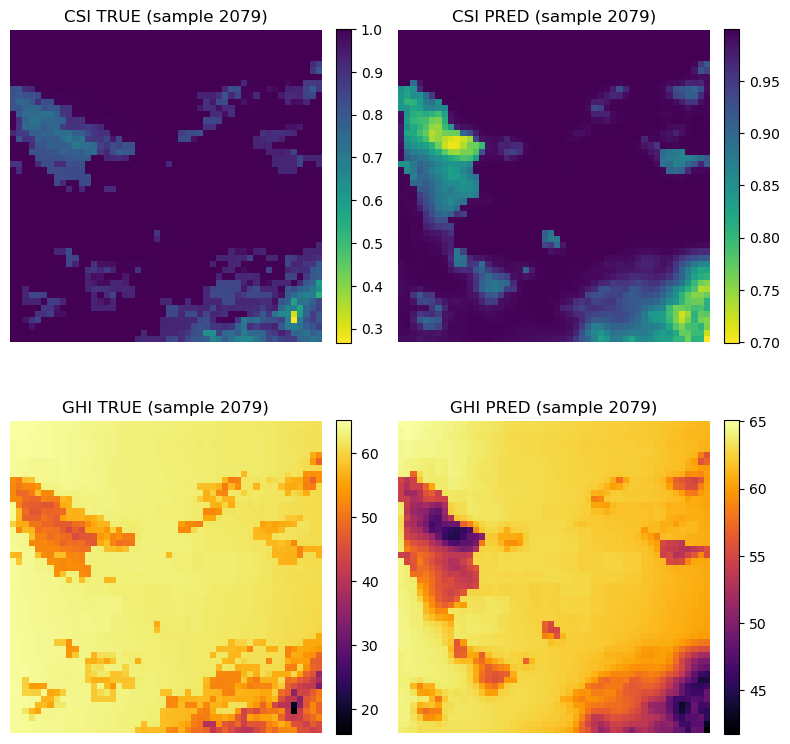

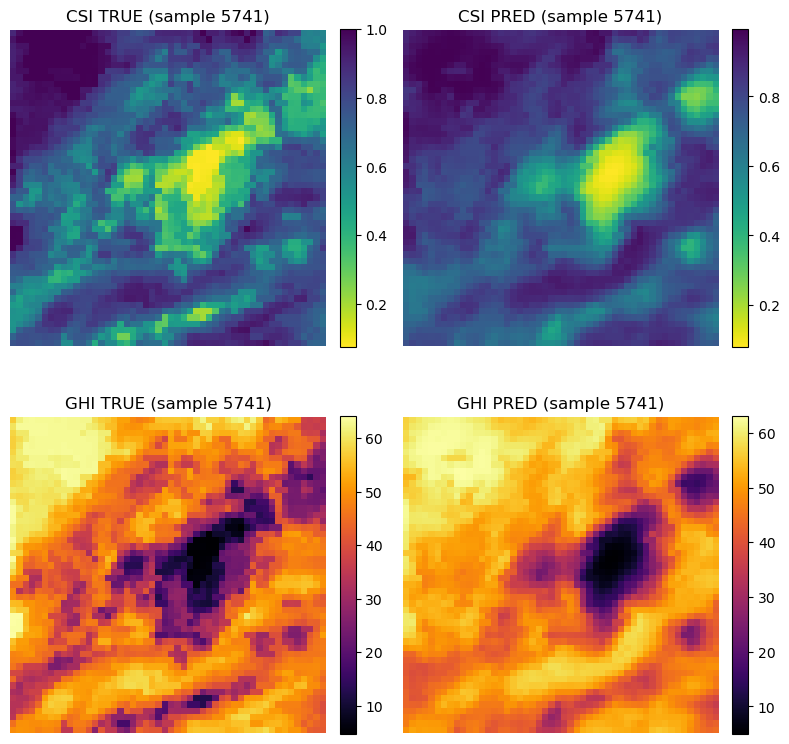

In [ ]:
ghi_cs_all = cams_data[:, 1, :, :] 
ghi_cs_test = ghi_cs_all[idx_test]
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (T_test,H,W)
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=5,
    seed=42
)